In [1]:
dataset = "mnist_red30_sml"
root = "/Users/federicogiannini/Library/CloudStorage/OneDrive-PolitecnicodiMilano/SML_CL"
nconfs = 10

In [2]:
import pickle
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
def plot_kappa(perf, dataset):
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8,5))
    for m in perf:
        ax.plot(perf[m], label=m, linestyle="-")
        ax.scatter(x=np.arange(0,len(perf[m])), y=perf[m], s=15)
    ax.set_xticks(np.arange(0,len(perf[m])))
    ax.set_xticklabels([f"c_{i}" for i in range(0,len(perf[m]))])
    ax.legend(loc="best")
    ax.set_title(dataset)
    ax.set_xlabel("Concepts", loc="right")
    ax.set_ylabel("Cohen's Kappa", loc="top")
    plt.tight_layout()
    plt.grid()
    plt.savefig(os.path.join(root, "performance", f"{dataset}_kappa_cl.png"), dpi=300)

In [4]:
cl_tables = []
for conf in range(1, nconfs+1):
    with open(os.path.join(root, "performance", f"{dataset}_{conf}conf", "cl_table_sml.pkl"), "rb") as f:
        table = pickle.load(f)
    with open(os.path.join(root, "performance", f"{dataset}_{conf}conf", "cl_table_cl.pkl"), "rb") as f:
        table.update(pickle.load(f))
    cl_tables.append(table)

In [5]:
cl_table = {}
for m in cl_tables[0]:
    cl_table[m] = {}
    for metric in ["accuracy", "kappa"]:
        cl_table[m][metric] = np.mean(np.array([table[m][metric] for table in cl_tables]), axis=0)

cumulative = []
for conf in range(nconfs):
    cumulative.append({})
    for m in cl_tables[conf]:
        cumulative[-1][m] = []
        for i in range(len(cl_tables[conf][m]["kappa"])):
            cumulative[-1][m].append(np.mean(cl_tables[conf][m]["kappa"][i][:i+1]))
            
cumulative_final = {}
for m in cumulative[0]:
    cumulative_final[m] = np.mean(np.array([c[m] for c in cumulative]), axis=0)

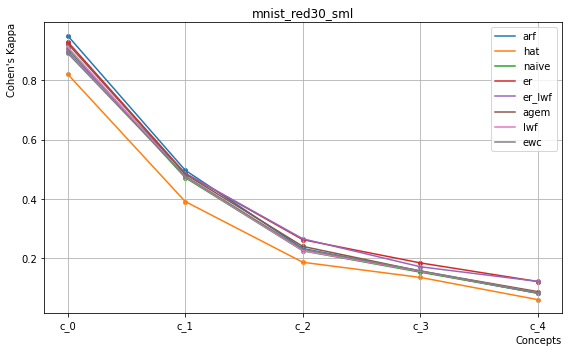

In [6]:
plot_kappa(cumulative_final, dataset)

In [7]:
cl_metrics = []
for conf, table in enumerate(cl_tables):
    cl_metrics.append({})
    for m in table:
        n = len(table[m]["kappa"])
        cl_metrics[-1][m] = {
            "average": np.mean(table[m]["kappa"][-1]),
            "a_metric": np.sum(
                [
                    table[m]["kappa"][i][j]
                    for i in range(n)
                    for j in range(i+1)
                ]
            )
            / (n * (n + 1) / 2),
            "bwt": np.sum(
                [
                    (
                        table[m]["kappa"][i][j]
                        - table[m]["kappa"][j][j]
                    )
                    for i in range(1, n)
                    for j in range(i)
                ]
            ) / (n * (n - 1) / 2),
            "conf": conf+1
        }  

for i in range(len(cl_metrics)):
    cl_metrics[i] = pd.DataFrame(cl_metrics[i]).T.reset_index().rename(columns={'index': 'model'})
    
cl_metrics = pd.concat(cl_metrics)

In [8]:
cl_metrics.to_excel(os.path.join(root, "performance", f"{dataset}_cl_metrics_all.xlsx"), index=False)
cl_metrics.groupby("model").mean().drop(columns="conf").reset_index().sort_values("a_metric", ascending=False).to_excel(os.path.join(root, "performance", f"{dataset}_cl_metrics.xlsx"), index=False)